In [2]:
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send
from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
import operator
from pprint import pprint
from IPython.display import Image, display
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
import litellm
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
litellm.ssl_verify = False

Orchestrator - worker pattern

In [5]:
class Dish(BaseModel):
    name: str = Field(
        description="Name of the dish (for example, Spaghetti Bolognese, Chicken Curry)."
    )
    ingredients: List[str] = Field(
        description="List of ingredients needed for this dish, separated by commas."
    )
    location: str = Field(
        description="The cuisine or cultural origin of the dish (for example, Italian, Indian, Mexican)."
    )

class Dishes(BaseModel):
    sections: List[Dish] = Field(
        description="A list of grocery sections, one for each dish, with ingredients."
    )

In [6]:
dish_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an assistant that generates a structured grocery list.\n\n"),
        (
        "human",
        "The user wants to prepare the following meals: {meals}\n\n"
        "For each meal, return a section with:\n"
        "- the name of the dish\n"
        "- a comma-separated list of ingredients needed for that dish.\n"
        "- the cuisine or cultural origin of the food"
    )
])

In [7]:
planner_pipe = dish_prompt | llm.with_structured_output(Dishes)
planner_pipe.invoke({ "meals" : ["banana smoothie", "carrot cake"]})

Dishes(sections=[Dish(name='Banana Smoothie', ingredients=['Banana', 'Milk', 'Yogurt', 'Honey', 'Ice'], location='Western'), Dish(name='Carrot Cake', ingredients=['Carrots', 'Flour', 'Sugar', 'Eggs', 'Oil', 'Cinnamon', 'Nutmeg', 'Baking soda', 'Baking powder', 'Cream cheese', 'Butter', 'Powdered sugar', 'Vanilla extract'], location='Western')])

State

In [26]:
class State(TypedDict):
    meals: str
    sections: List[Dish]
    completed_menu: Annotated[List[str], operator.add]
    final_meal_guide: str

In [27]:
dummy_state: State = {
    "meals": "Spaghetti Bolognese and Chicken Stir Fry",
    "sections": [],
    "completed_menu": [],
    "final_meal_guide": ""
}
report_sections = planner_pipe.invoke({"meals": dummy_state['meals']})

In [28]:
for i, section in enumerate(report_sections.sections):
    print(f"Dish {i+1}\n")
    # add each dish to our dummy state
    dummy_state["sections"].append(section)
    print(f"Item Name: {section.name}")
    print(f"Location/Cuisine: {section.location}")
    print(f"Ingredients: {", ".join(section.ingredients)}.")

Dish 1

Item Name: Spaghetti Bolognese
Location/Cuisine: Italian
Ingredients: Spaghetti, Ground beef, Canned tomatoes, Onion, Garlic, Carrots, Celery, Red wine, Olive oil, Herbs (oregano, basil).
Dish 2

Item Name: Chicken Stir Fry
Location/Cuisine: Asian
Ingredients: Chicken breast, Soy sauce, Ginger, Garlic, Broccoli, Carrots, Bell peppers, Rice noodles, Sesame oil, Vegetable oil.


Orchestrator node

In [29]:
def orchestrator(state: State):
    dish_descriptions = planner_pipe.invoke({"meals": state["meals"]})
    return {"sections": dish_descriptions.sections}

Worker node

In [30]:
chef_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a world-class chef from {location}.\n\n"),
        ("human",
        "Please introduce yourself briefly and present a detailed walkthrough for preparing the dish: {name}.\n"
        "Your response should include:\n"
        "- Start with hello with your  name and culinary background\n"
        "- A clear list of preparation steps\n"
        "- A full explanation of the cooking process\n\n"
        "Use the following ingredients: {ingredients}."
    )
])

In [31]:
chef_pipe = chef_prompt | llm

In [32]:
class WorkerState(TypedDict):
    section: Dish
    completed_menu: Annotated[list, operator.add]

In [33]:
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("chef_worker", {"section": s}) for s in state["sections"]]

In [34]:
def chef_worker(state: WorkerState):
    """Worker node that generates the cooking instructions for one meal section."""

    # Use the language model to generate a meal preparation plan
    # The model receives the dish name, location, and ingredients from the current section
    meal_plan = chef_pipe.invoke({
        "name": state["section"].name,
        "location": state["section"].location,
        "ingredients": state["section"].ingredients
    })

    # Return the generated meal plan wrapped in a list under completed_sections
    # This will be merged into the main state using operator.add in LangGraph
    return {"completed_menu": [meal_plan.content]}

In [35]:
dummy_dishes: List[Dish] = dummy_state["sections"]

# simulate LangGraph's fan-out and merging behavior
for section in dummy_dishes:
    # construct individual WorkerState
    worker_state: WorkerState = {
        "section": section,
        "recipe": []  # LangGraph merges this later
    }

    # call the worker logic directly
    result = chef_worker(worker_state)

    # merge the result into combined menu (LangGraph would do this with operator.add)
    dummy_state["completed_menu"] += result["completed_menu"]

In [36]:
completed_menu_sections = "\n".join(dummy_state["completed_menu"])
print(completed_menu_sections[:1000])

Ciao a tutti! I am Chef Alessandro Rossi, and for generations, my family has poured their hearts and souls into the rich culinary traditions of Italy. From my nonna's bustling kitchen in Emilia-Romagna to the finest restaurants, I've dedicated my life to perfecting the art of authentic Italian cooking. For me, food is not just sustenance; it's love, it's history, it's pure passion on a plate.

Today, we embark on a journey to create a true masterpiece: **Spaghetti Bolognese**. But let me be clear, amici, this is not just any meat sauce. This is a rich, slow-cooked *ragù*, a symphony of flavors that tells a story with every bite. Forget what you think you know about "spaghetti bolognese" from fast-food places – we are going to craft the real deal, a dish that will transport you straight to the heart of Italy!

---

### The Ingredients: Our Palette of Flavors

Before we begin our culinary dance, let's gather our beautiful ingredients. Freshness is key!

*   **Spaghetti:** Of course! A go

In [37]:
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # list of completed sections
    completed_sections = state["completed_menu"]

    # format completed section to str to use as context for final sections
    completed_menu = "\n\n---\n\n".join(completed_sections)

    return {"final_meal_guide": completed_menu}

Building a workflow

In [38]:
orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("chef_worker", chef_worker)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

In [39]:
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["chef_worker"] # source node, routing function, list of allowed targets
)

In [40]:
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_edge("chef_worker", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

In [41]:
orchestrator_worker = orchestrator_worker_builder.compile()

Visualization

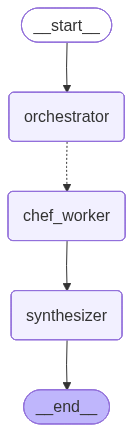

In [42]:
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

Testing

In [43]:
state = orchestrator_worker.invoke({"meals": "Steak and eggs, tacos, and chili"})

In [44]:
pprint(state["final_meal_guide"][:2000])

('Hey there, I\'m Chef Mike "Iron Skillet" Sullivan, and it\'s a pleasure to '
 'connect with you. My culinary journey has been deeply rooted in the heart of '
 'American cuisine, from the bustling kitchens of classic diners to the '
 "refined atmosphere of steakhouses across the country. I'm all about "
 'celebrating simple, quality ingredients and elevating them with time-honored '
 'techniques to create dishes that are both comforting and incredibly '
 'satisfying.\n'
 '\n'
 "Today, we're diving into a true American classic: **Steak and Eggs**. It's a "
 'dish that perfectly embodies hearty breakfast, a late brunch, or even a '
 'robust dinner. It’s about perfectly cooked protein, rich flavor, and a meal '
 'that truly sticks to your ribs.\n'
 '\n'
 "Let's get cooking!\n"
 '\n'
 '---\n'
 '\n'
 "### **The Ingredients We'll Be Using:**\n"
 '\n'
 '*   **Steak:** (e.g., a good quality New York Strip, Ribeye, or Sirloin, '
 'about 1-1.5 inches thick)\n'
 '*   **Eggs:** (2-3 large eggs pe

Reflection pattern

State

In [45]:
grades = Literal[
    "ultra-conservative", 
    "conservative", 
    "moderate", 
    "aggressive", 
    "high risk"
]

class State(TypedDict):
    investment_plan: str
    investor_profile: str
    target_grade: grades
    feedback: str
    grade: grades
    n: int = 0

Setup node

In [46]:
grade_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an investment advisor. Given the investor’s profile and their proposed plan,"
     "choose exactly one risk classification from: ultra-conservative, conservative, moderate, aggressive, high risk."
     "Return ONLY the grade."
    ),
    ("user",
     "Investor profile:\n\n{investor_profile}\n\n"
    )
])

grade_pipe = grade_prompt | llm

In [47]:
def determine_target_grade(state: State):
    """Ask the LLM to pick the best-fitting target_grade."""
    response = grade_pipe.invoke({
        "investor_profile": state["investor_profile"]
    })
    
    # return as a plain dict so LangGraph can merge it into the state
    return {"target_grade": response.content.lower()}

In [48]:
# initialize empty state except for the user inputted investor profile
dummy_state: State = {
    "investment_plan": "",
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    ),
    "target_grade": "",
    "feedback": "",
    "grade": "",
    "n": 0
}

In [49]:
# get target grade
target_grade = determine_target_grade(dummy_state)
# update target grade with the returned dict
dummy_state.update(target_grade)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': '',
 'investor_profile': 'Age: 29\n'
                     'Salary: $110,000\n'
                     'Assets: $40,000\n'
                     'Goal: Achieve financial independence by age 45\n'
                     'Risk tolerance: High',
 'n': 0,
 'target_grade': 'high risk'}


Generator node

In [50]:
# inital generation, no feedback, only based on profile
cathie_wood_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are a bold, innovation-driven investment advisor inspired by Cathie Wood.

Your goal is to generate a high-conviction, forward-looking investment plan that embraces disruptive technologies,
emerging markets, and long-term growth potential. You are not afraid of short-term volatility as long as the upside is transformational.

Create an investment strategy tailored to the investor profile below. Prioritize innovation and high-reward opportunities,
such as artificial intelligence, biotechnology, blockchain, or renewable energy.

Respond with a concise investment plan in paragraph form.
"""
    ),
    ("human", "Investor profile:\n\n{investor_profile}")
])

cathie_wood_pipe = cathie_wood_prompt | llm

In [51]:
# evaluator output schema
class Feedback(BaseModel):
    grade: grades = Field(
        description="Classify the investment based on risk level, ranging from ultra-conservative to high risk."
    )
    feedback: str = Field(
        description="Provide reasoning for the risk classification assigned to the investment suggestion."
    )

Phase2: adaptive generation

In [52]:
ray_dalio_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are an investment advisor inspired by Ray Dalio's principles but with adaptive strategy generation.
Your goal is to create varied, scenario-aware investment plans that respond dynamically to economic conditions,
feedback, and the investor's evolving needs. You adapt your recommendations based on previous evaluations.

CORE PRINCIPLES:
- Environmental diversification across economic regimes (growth/inflation combinations)
- Risk parity weighting by volatility, not just dollar amounts
- Inflation-aware asset selection with real return focus
- Macroeconomic scenario planning and regime identification

ADAPTATION RULES based on feedback:
- If deemed "too conservative" → Increase growth equity allocation, add emerging markets, consider alternatives
- If deemed "too aggressive" → Add defensive assets, increase bond allocation, focus on dividend stocks
- If "lacks inflation protection" → Emphasize TIPS, commodities, REITs, international exposure
- If "too complex" → Simplify to core ETF strategy with clear rationale
- If "insufficient diversification" → Add geographic, sector, or alternative asset exposure

ECONOMIC SCENARIO ADJUSTMENTS:
- Rising inflation environment → Emphasize commodities, TIPS, real estate, reduce duration
- Stagflation concerns → Focus on energy, materials, international markets, inflation hedges
- Deflationary risks → Increase government bonds, high-quality corporate bonds, cash positions
- Growth acceleration → Favor technology, consumer discretionary, small-cap growth
- Economic uncertainty → Balance with "All Weather" approach using multiple asset classes

TARGETING 15% RETURNS through:
- Strategic overweighting of growth assets during favorable conditions
- Tactical allocation adjustments based on economic regime
- Alternative investments (REITs, commodities, international) for diversification
- Leverage consideration for qualified investors
- Regular rebalancing to capture volatility

Respond with a clear, actionable investment plan that reflects current economic conditions 
and adapts to the specific feedback provided. Vary your approach significantly based on 
the grade and feedback received.
"""
    ),
    ("human",
     """Investor profile:
{investor_profile}

Previous strategy grade: {grade}

Evaluator feedback: {feedback}

Based on this feedback, create a NEW investment strategy that addresses the concerns raised 
while targeting 15% returns. Make significant adjustments from any previous approach.
""")
])

ray_dalio_pipe = ray_dalio_prompt | llm

Build the generator node

In [53]:
def investment_plan_generator(state: State) -> dict:
    """Prompts an LLM to generate or improve an investment plan based on the current state."""

    if state.get("feedback"):
        # use Ray Dalio–style generator when feedback is available
        response = ray_dalio_pipe.invoke({
            "investor_profile": state["investor_profile"],
            "grade": state["grade"],
            "feedback": state["feedback"]
        })
    else:
        # use Cathie Wood–style generator for initial plan
        response = cathie_wood_pipe.invoke({
            "investor_profile": state["investor_profile"]
        })

    return {"investment_plan": response.content}

In [54]:
# get the investment plan
initial_investment_plan = investment_plan_generator(dummy_state)
# update the dummy state with generated plan
dummy_state.update(initial_investment_plan)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': 'Given your age, high risk tolerance, and ambitious goal '
                    'of achieving financial independence by 45, we will '
                    'construct a high-conviction investment plan focused '
                    'relentlessly on the most disruptive innovations poised '
                    'for exponential growth over the next decade. Your '
                    '$40,000, along with future contributions, will be '
                    'strategically allocated into a concentrated portfolio '
                    'targeting transformational upside, embracing short-term '
                    'volatility as a necessary component of long-term value '
                    'creation. Our core themes will include the Artificial '
                    'Intelligence revolution, from foundational AI '
                    'infrastructure and models to advanced applications and '
                    'robotics; the Genomic Revolution, enco

Evaluator node

In [55]:
# Warren Buffet style evaluation prompt
evaluator_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """You are an investment risk evaluator inspired by Warren Buffett's value investing philosophy.

Your task is to assess whether a proposed investment strategy aligns with conservative, value-driven principles 
that emphasize capital preservation, long-term stability, and sound business fundamentals. You should be 
skeptical of speculative investments, high-volatility assets, and short-term market trends.

RISK CLASSIFICATION LEVELS:
- ultra-conservative: Extremely safe, minimal risk of loss
- conservative: Low risk, prioritizes capital preservation  
- moderate: Balanced approach with acceptable risk-reward ratio
- aggressive: Higher risk for potentially greater returns
- high risk: Speculative investments with significant loss potential

EVALUATION CRITERIA:
- Business clarity: Is the investment easily understandable with transparent cash flows?
- Margin of safety: Does the investment price provide protection against downside risk?
- Capital preservation: Will this strategy protect wealth over the long term?
- Investor alignment: Does this match a conservative investor's risk tolerance and goals?
- Quality fundamentals: Are the underlying assets financially sound with competitive advantages?

Return your assessment in the following  format:
{{
  "grade": "<investment risk level>",
  "feedback": "<concise explanation of the assigned risk level and key reasoning>"
}}
"""
    ),
    ("human", 
     "Evaluate this investment plan:\n\n{investment_plan}\n\nFor this investor profile:\n\n{investor_profile}\n\nAnd provide feedback that matches this target risk level: {target_grade}")
])

# create the pipe with the structured output that outputs a Feedback object
buffett_evaluator_pipe = evaluator_prompt | llm.with_structured_output(Feedback)

Build the generator node

In [56]:
def evaluate_plan(state: State):
    """LLM evaluates the investment plan"""

    # add one to the current count
    current_count = state.get('n', 0) + 1

    # get the evaluation result from the evaluator pipe
    evaluation_result = buffett_evaluator_pipe.invoke({
        "investment_plan": state["investment_plan"],
        "investor_profile": state["investor_profile"],
        "target_grade": state["target_grade"]
    })

    # return the grade and feedback in a dict
    return {"grade": evaluation_result.grade, "feedback": evaluation_result.feedback, "n": current_count}

In [57]:
# get the feedback
evaluated_feedback = evaluate_plan(dummy_state)
# update the dummy state with the feedback
dummy_state.update(evaluated_feedback)

In [58]:
print(f"Grade: {dummy_state["grade"]}")
print(f"Feedback: {dummy_state["feedback"]}")

Grade: high risk
Feedback: This investment plan is classified as 'high risk' from a value investing perspective. It explicitly targets disruptive innovations and exponential growth sectors, which inherently carry significant uncertainty and lack predictable cash flows. The focus on a concentrated portfolio, embracing short-term volatility, and seeking 'transformational upside' at 29 with $40,000 assets leaves little to no margin of safety. While the investor's stated risk tolerance is high, this strategy prioritizes speculative growth over capital preservation and sound business fundamentals, making it highly speculative and prone to significant capital loss, which is contrary to conservative, value-driven principles.


Routing node

In [59]:
def route_investment(state: State, iteration_limit: int = 5):
    """Route investment based on risk grade evaluation"""
    # get grades
    current_grade = state.get("grade", "MISSING")
    target_grade = state.get("target_grade", "MISSING")
    # check if grades match
    match = current_grade == target_grade

    # print out the tracked values
    print(f"=== ROUTING  ===")
    print(f"Current grade: '{current_grade}'")
    print(f"Target risk profile: '{target_grade}'")
    print(f"Match: {match}")
    print(f"Number of trials: {state['n']}")

    # routing logic
    if match: # grades match
        print("→ Routing to: Accepted")
        return "Accepted"
    elif state['n'] > iteration_limit: # review iterations exceeds limit
        print("→ Too many iterations, stopping")
        return "Accepted"
    else: # grades don't match
        print("→ Routing to: Rejected + Feedback")
        return "Rejected + Feedback"

Building the workflow

In [60]:
# initialize StateGraph with the given State schema
optimizer_builder = StateGraph(State)

# add the setup, generator, and evaluator nodes
optimizer_builder.add_node("determine_target_grade", determine_target_grade)
optimizer_builder.add_node("investment_plan_generator", investment_plan_generator)
optimizer_builder.add_node("evaluate_plan", evaluate_plan)

# define the flow with edges
optimizer_builder.add_edge(START, "determine_target_grade")
optimizer_builder.add_edge("determine_target_grade", "investment_plan_generator")
optimizer_builder.add_edge("investment_plan_generator", "evaluate_plan")

Conditional routing

In [61]:
# add conditional edge for reflection
optimizer_builder.add_conditional_edges(
    "evaluate_plan",
    lambda state: route_investment(state),
    {
        "Accepted": END,
        "Rejected + Feedback": "investment_plan_generator",
    },
)

In [62]:
# compile the workflow
optimizer_workflow = optimizer_builder.compile()

Visualization

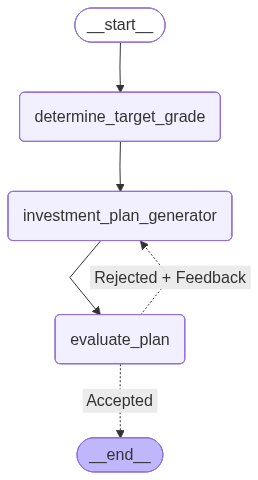

In [63]:
# display the graph
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

Testing

In [64]:
# invoke the workflow with an example investor profile
state = optimizer_workflow.invoke({
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    )
})

=== ROUTING  ===
Current grade: 'high risk'
Target risk profile: 'high risk'
Match: True
Number of trials: 1
→ Routing to: Accepted


In [65]:
def pretty_print_final_state(state: dict):
    print("🎯 Final Investment Plan Summary\n" + "="*40)
    print(f"\n📌 Investor Profile:\n{state['investor_profile']}")
    
    print("\n📈 Target Risk Grade:", state['target_grade'])
    print("📊 Final Assigned Grade:", state['grade'])
    print("🔁 Iterations Taken:", state['n'])

    print("\n📝 Evaluator Feedback:\n" + "-"*30)
    print(state['feedback'])

    print("\n📃 Final Investment Plan:\n" + "-"*30)
    print(state['investment_plan'])

pretty_print_final_state(state)

🎯 Final Investment Plan Summary

📌 Investor Profile:
Age: 29
Salary: $110,000
Assets: $40,000
Goal: Achieve financial independence by age 45
Risk tolerance: High

📈 Target Risk Grade: high risk
📊 Final Assigned Grade: high risk
🔁 Iterations Taken: 1

📝 Evaluator Feedback:
------------------------------
This strategy is highly speculative, focusing entirely on disruptive innovation and exponential growth sectors like AI and blockchain. While potentially offering high returns, it carries significant risk due to the inherent unpredictability of these emerging technologies, often lacking clear, stable cash flows and robust financial fundamentals. The absence of a margin of safety and the explicit acceptance of high volatility make capital preservation highly uncertain, directly conflicting with conservative value investing principles. This approach is more akin to venture capital than public market value investing, suitable only for investors with extreme risk tolerance willing to accept s